In [26]:
import numpy as np
import pandas as pd
dt = pd.DataFrame({"cgpa":[8,7,6,5],
                   "PS":[8,9,10,5],
                   'placed':[1,1,0,0]})

In [27]:
X=dt[['cgpa','PS']]
X

,cgpa,PS
0,8,8
1,7,9
2,6,10
3,5,5


In [28]:
y= dt['placed']
y

0    1
1    1
2    0
3    0
Name: placed, dtype: int64

In [29]:
X=np.array(X)

In [30]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [31]:
alpha = 0.001
epochs =50
m=4

W1=np.random.random(size=(2,2))
B1=np.random.random(size=(2,1))
W2=np.random.random(size=(2,1))
B2=np.random.random(size=(1,1))

avg_loss = []
epochs_count = []
for i in range(epochs):
  arr=np.arange(X.shape[0])
  np.random.shuffle(arr)
  X=X[arr]
  print(f"Epoch : {i}")
  loss=[]
  for j in range(m):
    #Forward Propagation
    #Layer 1
    zp= W1.T@X[j].reshape(-1, 1)+B1
    o1 = sigmoid(zp)
    #Layer 2
    zf = W2.T@o1+B2
    ypred = sigmoid(zf)
    ytrue = y[j]
    #loss
    l = -ytrue*np.log(ypred) - (1-ytrue)*np.log(1-ypred)
    loss.append(l)
    # Backward Propogation
    # partial derivatives
    # set 1
    delL_by_delo_21= -ytrue/ypred +(1-ytrue)/(1-ypred)
    delo_21_by_delzf= sigmoid(zf)*(1-sigmoid(zf))
    delzf_by_delw2_11 = o1[0]
    delzf_by_delw2_21= o1[1]
    delzf_by_delb21 = 1
    delL_by_delw2_11 = delL_by_delo_21 * delo_21_by_delzf * delzf_by_delw2_11
    delL_by_delw2_21 = delL_by_delo_21 * delo_21_by_delzf * delzf_by_delw2_21
    delL_by_delb21 = delL_by_delo_21 * delo_21_by_delzf * delzf_by_delb21
     # set 2
    delL_by_delw1_11 = -(ytrue-ypred)*W2[0]*o1[0]*(1-o1[0])*X[j,0]
    delL_by_delw1_21 = -(ytrue-ypred)*W2[0]*o1[0]*(1-o1[0])*X[j,1]
    delL_by_delb11 = -(ytrue-ypred)*W2[0]*o1[0]*(1-o1[0])
     # set 3
    delL_by_delw1_12 = -(ytrue-ypred)*W2[1]*o1[1]*(1-o1[1])*X[j,0]
    delL_by_delw1_22 = -(ytrue-ypred)*W2[1]*o1[1]*(1-o1[1])*X[j,1]
    delL_by_delb12 = -(ytrue-ypred)*W2[1]*o1[1]*(1-o1[1])
    # gradient descent updates
    # set 1
    W2[0][0] = W2[0][0] - alpha*delL_by_delw2_11[0][0]
    W2[1][0] = W2[1][0] - alpha*delL_by_delw2_21[0][0]
    B2[0][0] = B2[0][0] - alpha*delL_by_delb21[0][0]
    # set 2
    W1[0][0] = W1[0][0] - alpha*delL_by_delw1_11[0][0]
    W1[1][0] = W1[1][0] - alpha*delL_by_delw1_21[0][0]
    B1[0][0] = B1[0][0] - alpha*delL_by_delb11[0][0]
    # set 3
    W1[0][1] = W1[0][1] - alpha*delL_by_delw1_12[0][0]
    W1[1][1] = W1[1][1] - alpha*delL_by_delw1_22[0][0]
    B1[1][0] = B1[1][0] - alpha*delL_by_delb12[0][0]

  avg_loss.append(np.mean(loss))
  print(f"Avg Loss : {np.mean(loss)}")
  epochs_count.append(i)

Epoch : 0
Avg Loss : 0.8320576184971609
Epoch : 1
Avg Loss : 0.8313339059296265
Epoch : 2
Avg Loss : 0.8328781974237203
Epoch : 3
Avg Loss : 0.8299531884010897
Epoch : 4
Avg Loss : 0.8292393776128648
Epoch : 5
Avg Loss : 0.8285167683416385
Epoch : 6
Avg Loss : 0.830008669882925
Epoch : 7
Avg Loss : 0.8271132849592957
Epoch : 8
Avg Loss : 0.8264123930184419
Epoch : 9
Avg Loss : 0.8278894538354549
Epoch : 10
Avg Loss : 0.827198810667201
Epoch : 11
Avg Loss : 0.8242598283655507
Epoch : 12
Avg Loss : 0.8236328282027213
Epoch : 13
Avg Loss : 0.8251057852990238
Epoch : 14
Avg Loss : 0.8244156106582132
Epoch : 15
Avg Loss : 0.8237411630229095
Epoch : 16
Avg Loss : 0.8231061123170802
Epoch : 17
Avg Loss : 0.8201625390613079
Epoch : 18
Avg Loss : 0.8195545855198778
Epoch : 19
Avg Loss : 0.821020890664937
Epoch : 20
Avg Loss : 0.818160029339725
Epoch : 21
Avg Loss : 0.8175486101499865
Epoch : 22
Avg Loss : 0.8168916084775144
Epoch : 23
Avg Loss : 0.8183670471987534
Epoch : 24
Avg Loss : 0.815595

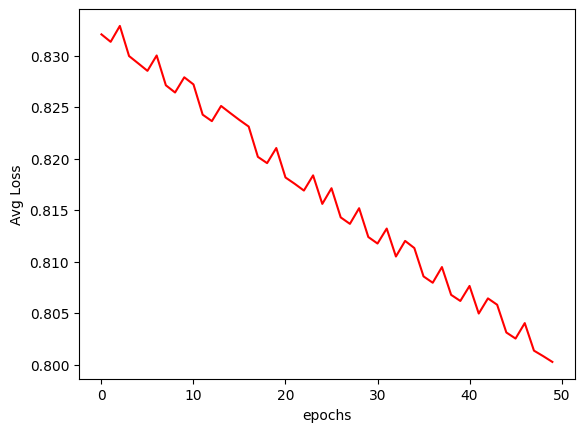

In [32]:
import matplotlib.pyplot as plt

plt.plot(epochs_count, avg_loss, c = "red")
plt.xlabel("epochs"); plt.ylabel("Avg Loss")
plt.show()